--- Initial Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    object 
 1   Date                                     267 non-null    object 
 2   Frequency                                267 non-null    object 
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    object 
 7   longitude                                267 non-null    float64
 8   latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB
None
           Region         D

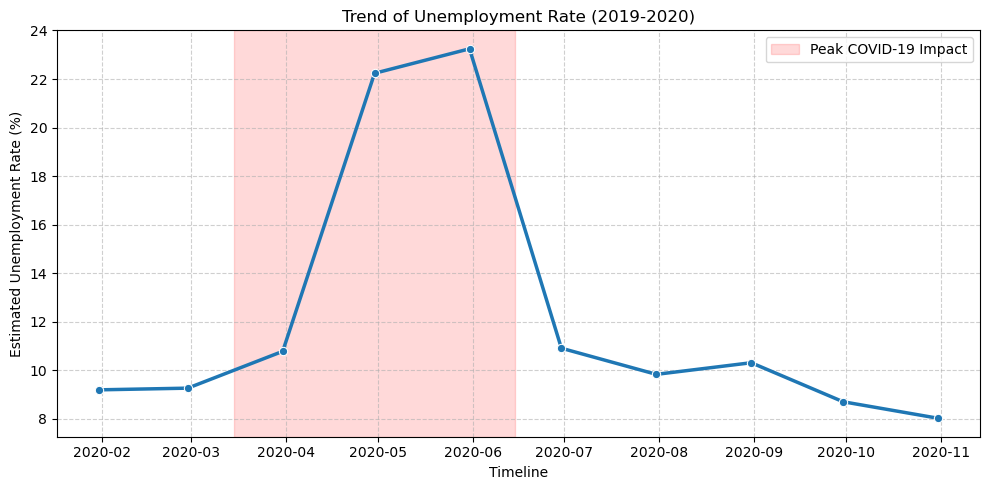

C:\Users\suloc\AppData\Local\Temp\ipykernel_4596\874199575.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


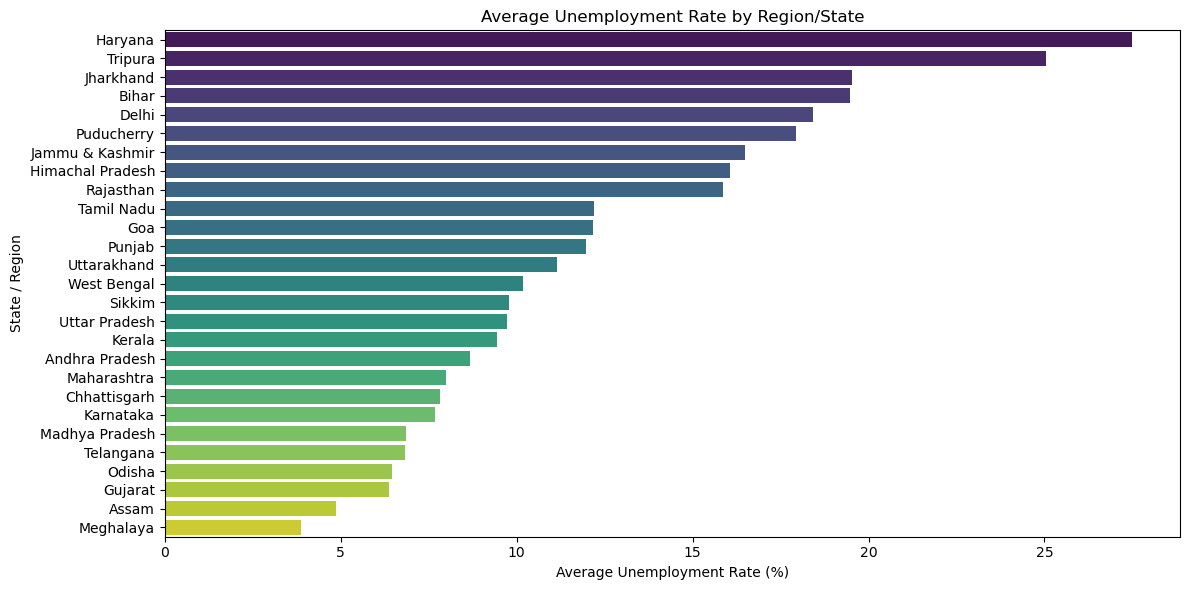

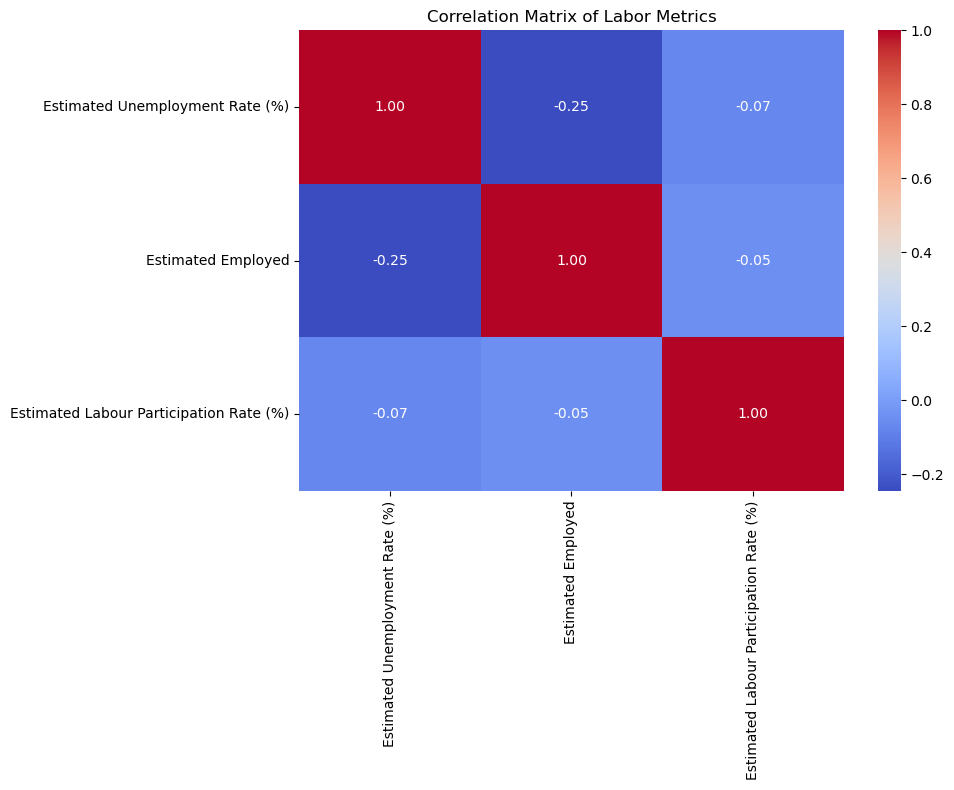

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load the Dataset
# Replace 'Unemployment_Rate_upto_11_2020.csv' with your local filename if different
try:
    df = pd.read_csv(r'\Users\suloc\Downloads\archive\Unemployment_Rate_upto_11_2020.csv')
except FileNotFoundError:
    # Fallback name for alternate Kaggle versions of the same dataset
    df = pd.read_csv(r'\Users\suloc\Downloads\archive\Unemployment in India.csv')

# Clean column spaces (this dataset often has leading/trailing spaces in column names)
df.columns = df.columns.str.strip()

print("--- Initial Data Structure ---")
print(df.info())
print(df.head())

# 2. Data Preprocessing & Cleaning
# Drop rows that are entirely null (common in some Kaggle versions)
df.dropna(inplace=True)

# Convert Date to datetime format format
df["Date"] = pd.to_datetime(df["Date"].str.strip(), dayfirst=True)

# Extract Month and Year for seasonal/trend analysis
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Month_Int"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# 3. Descriptive Analytics
print("\n--- Summary Statistics ---")
print(df.describe())

# 4. Data Visualization & Insights

# Insight 1: Timeline Trend (Highlighting the Covid-19 Lockdown Spike in April/May 2020)
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    errorbar=None,
    linewidth=2.5,
    marker="o",
)
plt.title("Trend of Unemployment Rate (2019-2020)")
plt.xlabel("Timeline")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.axvspan(
    pd.Timestamp("2020-03-15"),
    pd.Timestamp("2020-06-15"),
    color="red",
    alpha=0.15,
    label="Peak COVID-19 Impact",
)
plt.legend()
plt.tight_layout()
plt.show()

# Insight 2: Regional Analysis (Which states/regions suffered the most?)
region_stats = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
    .sort_values(by="Estimated Unemployment Rate (%)", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_stats, x="Estimated Unemployment Rate (%)", y="Region", palette="viridis"
)
plt.title("Average Unemployment Rate by Region/State")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State / Region")
plt.tight_layout()
plt.show()

# Insight 3: Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Labor Metrics")
plt.tight_layout()
plt.show()